This unmodified version is:

* Slower
* Finds a suboptimal answer

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.utils import shuffle

In [2]:
# data is from: https://grouplens.org/datasets/movielens/
# in case the link changes in the future

!wget -nc http://files.grouplens.org/datasets/movielens/ml-20m.zip

File ‘ml-20m.zip’ already there; not retrieving.



In [3]:
!unzip -n ml-20m.zip

Archive:  ml-20m.zip


In [4]:
!ls

1.PyTorch-Linear-Regression.ipynb
10.PyTorch-Simple-RNN-Sine.ipynb
10.PyTorch-Simple-RNN-Sine1-with-noise.ipynb
11.PyTorch-Understanding-RNN-Shapes.ipynb
12.PyTorch-Nonlinear-Sequence-Simple-RNN.ipynb
12.PyTorch-Nonlinear-Sequence-linear.ipynb
13.PyTorch-Nonlinear-Sequence-LSTM.ipynb
14.PyTorch-RNN-Image-Classifier.ipynb
15.PyTorch-Stock-Returns.ipynb
16.PyTorch-Text-Processing.ipynb
17.Custom-PyTorch-Text-Classification-using-RNN.ipynb
18.Custom-PyTorch-Text-Classification-using-CNN.ipynb
19.PyTorch-Recommender-20M-Unmodified.ipynb
2.PyTorch-Regression-Moore's-Law.ipynb
3.PyTorch-Linear-Classification-with-Logits.ipynb
3.PyTorch-Linear-Classification.ipynb
4.PyTorch-ANN-MNIST.ipynb
5.PyTorch-Regression.ipynb
6.PyTorch-CNN-Fashion-MNIST.ipynb
7.PyTorch-CIFAR.ipynb
8.PyTorch-CIFAR-Improved.ipynb
9.PyTorch-Autoregressive-Model.ipynb
9.PyTorch-Autoregressive-Model1-with-Noise.ipynb
FashionMNIST
MNIST
Note.md
Resources
cifar-10-batches-py
cifar-10-python.tar.gz
images
machine_learning_exam

In [5]:
df = pd.read_csv('ml-20m/ratings.csv')
df.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


Next I load in the data using pandas and of course the data is a CSV so the first column is the user id, the second is the movie id, and then we have the rating and the timestamp, which we won't need.

In [6]:
# We can't trust the userId and movieId to be numbered 0...N-1
# Let's just set our own ids

# current_user_id = 0
# custom_user_map = {} # old user id > new user id
# def map_user_id(row):
#   global current_user_id, custom_user_map
#   old_user_id = row['userId']
#   if old_user_id not in custom_user_map:
#     custom_user_map[old_user_id] = current_user_id
#     current_user_id += 1
#   return custom_user_map[old_user_id]
# df['new_user_id'] = df.apply(map_user_id, axis=1)

df.userId = pd.Categorical(df.userId)
df['new_user_id'] = df.userId.cat.codes

In [7]:
# Now do the same thing for movie ids
# current_movie_id = 0
# custom_movie_map = {} # old movie id > new movie id
# def map_movie_id(row):
#   global current_movie_id, custom_movie_map
#   old_movie_id = row['movieId']
#   if old_movie_id not in custom_movie_map:
#     custom_movie_map[old_movie_id] = current_movie_id
#     current_movie_id += 1
#   return custom_movie_map[old_movie_id]
# df['new_movie_id'] = df.apply(map_movie_id, axis=1)

df.movieId = pd.Categorical(df.movieId)
df['new_movie_id'] = df.movieId.cat.codes

Then we can grab those ids by calling .cat.codes.

In [8]:
# Get user IDs, movie IDs, and ratings as separate arrays
user_ids = df['new_user_id'].values
movie_ids = df['new_movie_id'].values
ratings = df['rating'].values - 2.5

In [9]:
# Get number of users and number of movies
N = len(set(user_ids))
M = len(set(movie_ids))

# Set embedding dimension
D = 10

In [10]:
# Make a neural network
class Model(nn.Module):
  def __init__(self, n_users, n_items, embed_dim, n_hidden=1024):
    super(Model, self).__init__()
    self.N = n_users
    self.M = n_items
    self.D = embed_dim

    self.u_emb = nn.Embedding(self.N, self.D)
    self.m_emb = nn.Embedding(self.M, self.D)
    self.fc1 = nn.Linear(2 * self.D, n_hidden)
    self.fc2 = nn.Linear(n_hidden, 1)

  def forward(self, u, m):
    u = self.u_emb(u) # output is (num_samples, D)
    m = self.m_emb(m) # output is (num_samples, D)

    # merge
    out = torch.cat((u, m), 1) # output is (num_samples, 2D)

    # ANN
    out = self.fc1(out)
    out = F.relu(out)
    out = self.fc2(out)
    return out

We'll also set D of the embedding dimension.

In [11]:
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda:0" if torch.cuda.is_available() else "cpu"))
print(device)

mps


next we create a device object.

In [12]:
model = Model(N, M, D)
model.to(device)

Model(
  (u_emb): Embedding(138493, 10)
  (m_emb): Embedding(26744, 10)
  (fc1): Linear(in_features=20, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=1, bias=True)
)

In [13]:
# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())
# optimizer = torch.optim.SGD(model.parameters(), lr=0.08, momentum=0.9)

You know we create the loss and optimizer and we shuffle the data.

In [14]:
# shuffle the data in corresponding order
user_ids, movie_ids, ratings = shuffle(user_ids, movie_ids, ratings)

In [15]:
# convert to tensors
user_ids_t = torch.from_numpy(user_ids).long()
movie_ids_t = torch.from_numpy(movie_ids).long()
ratings_t = torch.from_numpy(ratings.astype(np.float32))

This is so that we effectively randomize the train test split, then we convert the data to torch tensors.

In [16]:
# Make datasets
Ntrain = int(0.8 * len(ratings))
train_dataset = torch.utils.data.TensorDataset(
    user_ids_t[:Ntrain],
    movie_ids_t[:Ntrain],
    ratings_t[:Ntrain],
)

test_dataset = torch.utils.data.TensorDataset(
    user_ids_t[Ntrain:],
    movie_ids_t[Ntrain:],
    ratings_t[Ntrain:],
)

Next we create data loader objects from our data sets.

In [17]:
# Data loaders
batch_size = 512
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                            batch_size=batch_size,
                                            shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                           batch_size=batch_size,
                                           shuffle=False)

You manually now previously the special vision and text libraries were doing that for us.

In [18]:
# A function to encapsulate the training loop
def batch_gd(model, criterion, optimizer, train_iter, test_iter, epochs):
  train_losses = np.zeros(epochs)
  test_losses = np.zeros(epochs)

  for it in range(epochs):
    t0 = datetime.now()
    train_loss = []
    for users, movies, targets in train_loader:
      targets = targets.view(-1, 1).float()

      # move data to GPU
      users, movies, targets = users.to(device), movies.to(device), targets.to(device)

      # zero the parameter gradients
      optimizer.zero_grad()

      # Forward pass
      outputs = model(users, movies)
      loss = criterion(outputs, targets)

      # Backward and optimize
      loss.backward()
      optimizer.step()

      train_loss.append(loss.item())

    # Get train loss and test loss
    train_loss = np.mean(train_loss) # a little misleading

    test_loss = []
    for users, movies, targets in test_loader:
      users, movies, targets = users.to(device), movies.to(device), targets.to(device)
      targets = targets.view(-1, 1).float()
      outputs = model(users, movies)
      loss = criterion(outputs, targets)
      test_loss.append(loss.item())
    test_loss = np.mean(test_loss)

    # Save losses
    train_losses[it] = train_loss
    test_losses[it] = test_loss

    dt = datetime.now() - t0
    print(f'Epoch {it+1}/{epochs}, Train Loss: {train_loss:.4f}, '
          f'Test Loss: {test_loss:.4f}, Duration: {dt}')

  return train_losses, test_losses

In [19]:
# train_losses, test_losses = batch_gd(
#     model, criterion, optimizer, train_loader, test_loader, 25)

In [20]:
# profile this using
%prun train_losses, test_losses = batch_gd( model, criterion, optimizer, train_loader, test_loader, 25)

Epoch 1/25, Train Loss: 0.8168, Test Loss: 0.7535, Duration: 0:03:48.988861
Epoch 2/25, Train Loss: 0.7394, Test Loss: 0.7370, Duration: 0:03:58.207268
Epoch 3/25, Train Loss: 0.7237, Test Loss: 0.7252, Duration: 0:03:46.677908
Epoch 4/25, Train Loss: 0.7081, Test Loss: 0.7139, Duration: 0:03:50.418690
Epoch 5/25, Train Loss: 0.6947, Test Loss: 0.7039, Duration: 0:03:50.749332
Epoch 6/25, Train Loss: 0.6853, Test Loss: 0.6988, Duration: 0:03:56.246940
Epoch 7/25, Train Loss: 0.6788, Test Loss: 0.6952, Duration: 0:03:50.620977
Epoch 8/25, Train Loss: 0.6738, Test Loss: 0.6919, Duration: 0:04:03.047333
Epoch 9/25, Train Loss: 0.6697, Test Loss: 0.6895, Duration: 0:04:49.639170
Epoch 10/25, Train Loss: 0.6661, Test Loss: 0.6891, Duration: 0:05:21.029251
Epoch 11/25, Train Loss: 0.6630, Test Loss: 0.6862, Duration: 0:05:36.041288
Epoch 12/25, Train Loss: 0.6602, Test Loss: 0.6852, Duration: 0:05:33.738427
Epoch 13/25, Train Loss: 0.6576, Test Loss: 0.6849, Duration: 0:05:25.449567
Epoch 14

         4266925658 function calls (4255399658 primitive calls) in 6252.976 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
  5664325 2093.892    0.000 2093.892    0.000 {method 'item' of 'torch._C.TensorBase' objects}
  2929800 1044.993    0.000 1044.993    0.000 {method 'to' of 'torch._C.TensorBase' objects}
2000026300 1020.006    0.000 1020.006    0.000 dataset.py:206(<genexpr>)
  2929800  461.338    0.000  461.338    0.000 {built-in method torch.stack}
500006575  206.639    0.000 1226.645    0.000 dataset.py:205(__getitem__)
   781275  179.399    0.000  179.399    0.000 {method 'run_backward' of 'torch._C._EngineBase' objects}
   976650  165.212    0.000 2190.757    0.002 dataloader.py:783(_next_data)
3906400/976600  139.890    0.000  689.413    0.001 collate.py:118(collate)
  4687650  132.222    0.000  132.222    0.000 {method 'addcmul_' of 'torch._C.TensorBase' objects}
  4687650  129.062    0.000  129.062    0.000 {m

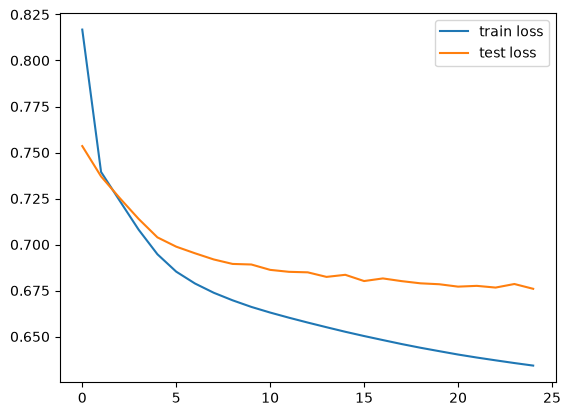

In [21]:
# Plot the train loss and test loss per iteration
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()
plt.show()